In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import re
from PIL.ImageColor import colormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from pathlib import Path

In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root folder named '{project_folder_name}'.")
print("Project root path:" + str(project_root))
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from model.dynamic import PEMFC_dyn
from model.static import PEMFC_stat
from model.coefficients import *
from configuration.initialize import *

Project root path:d:\MFC2024


## In this file the massflow dynamic is compared.
### For the gas channel dynamic, following assumption is given:
The time constant of supply manifold is large, but reasonable value.
The inlet and outlet velocity of the static model are assumed empirically, using the dynamic value as the reference.

In [3]:
I_points = [10, 20, 30, 40, 50]

dyn_log_all = {}

for RHC in [0, 0.5]:
    for P_des in [1.3,1.4,1.5]:
        for T_des in [50,60,70]:
            if RHC == 0 and P_des != 1.3:
                continue # Skip the condition that not yet carried out on the experimental side
            else:
                pass

            states_dyn_log = []
            time_evolutions = []
            massflow_dyn_log = []

            for I_LOAD in I_points:
                # --------------- Dynamic Simulation  --------------- #
                operating_inputs["Phi_c_des"] = RHC 
                operating_inputs["Pa_des"] = P_des * 1e5
                operating_inputs["Pc_des"] = P_des * 1e5
                operating_inputs["Tfc"] = T_des + 273.15
                operating_inputs["current_density"] = lambda x: I_LOAD/parameters["Aact"]
                model = PEMFC_dyn(parameters,operating_inputs, init_x(operating_inputs, parameters))
                sol = solve_ivp(model.dxdt, (0, 90), init_x(operating_inputs, parameters), method='BDF', max_step=1e-1)
                model._recovery(sol)
                # --------------- Log states for dynamic simulation  --------------- #
                states = {} # Log the last state values for each variable => pseudo steady-state values 
                time_evo = {} # Log the time evolution of each variable => check for convergence to steady-state
                for key, var_name in enumerate(model.variables):
                    states[var_name] = model.variables[var_name][-1]
                    time_evo[var_name] = model.variables[var_name]
                for key, var_name in enumerate(model.elec_variables):
                    states[var_name] = model.elec_variables[var_name][-1]
                    time_evo[var_name] = model.elec_variables[var_name]
                massflow_dyn = model.calculate_flows(sol.t[-1], states)

                states_dyn_log.append(states)
                time_evolutions.append(time_evo)
                massflow_dyn_log.append(massflow_dyn)
                
            # --------------- Log states profile for both simulations  --------------- #
            states_profile_dyn = {}
            for key, value in enumerate(states_dyn_log[0].keys()):
                states_profile_dyn[value] = [states[value] for states in states_dyn_log]
            dyn_log_all["RHA"+str(0)+"/RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_profile_dyn, "time_evolution":time_evolutions, "massflow": massflow_dyn_log}

In [16]:
stat_log_all = {}

for RHC in [0, 0.5]:
    for P_des in [1.3,1.4,1.5]:
        for T_des in [50,60,70]:
            if RHC == 0 and P_des != 1.3:
                continue # Skip the condition that not yet carried out on the experimental side
            else:
                pass
            states_stat = []
            for I_LOAD in I_points:
                # --------------- Steady-state Simulation  --------------- #
                Wout_c = 8 + I_LOAD * 0.25
                Win_c = 3 + I_LOAD * 0.3
                operating_inputs_stat = {'Tfc': T_des + 273.15, 'Phi_a_des': 0, 'Phi_c_des': RHC,
                                                             'Pa_des': P_des * 1e5, 'Pc_des': P_des * 1e5,
                                                             'Win_c': Win_c, 'Wout_c': Wout_c, 'Win_a': 4.8, 'Wout_a': 6.8}
                model = PEMFC_stat(parameters,operating_inputs_stat)
                sol = model.solve(I_LOAD/parameters['Aact'])
                # --------------- Log states for steady-state simulation  --------------- #
                states_stat.append(sol)
            # --------------- Log states for both simulations  --------------- #
            stat_log_all["RHA"+str(0)+"/RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_stat}

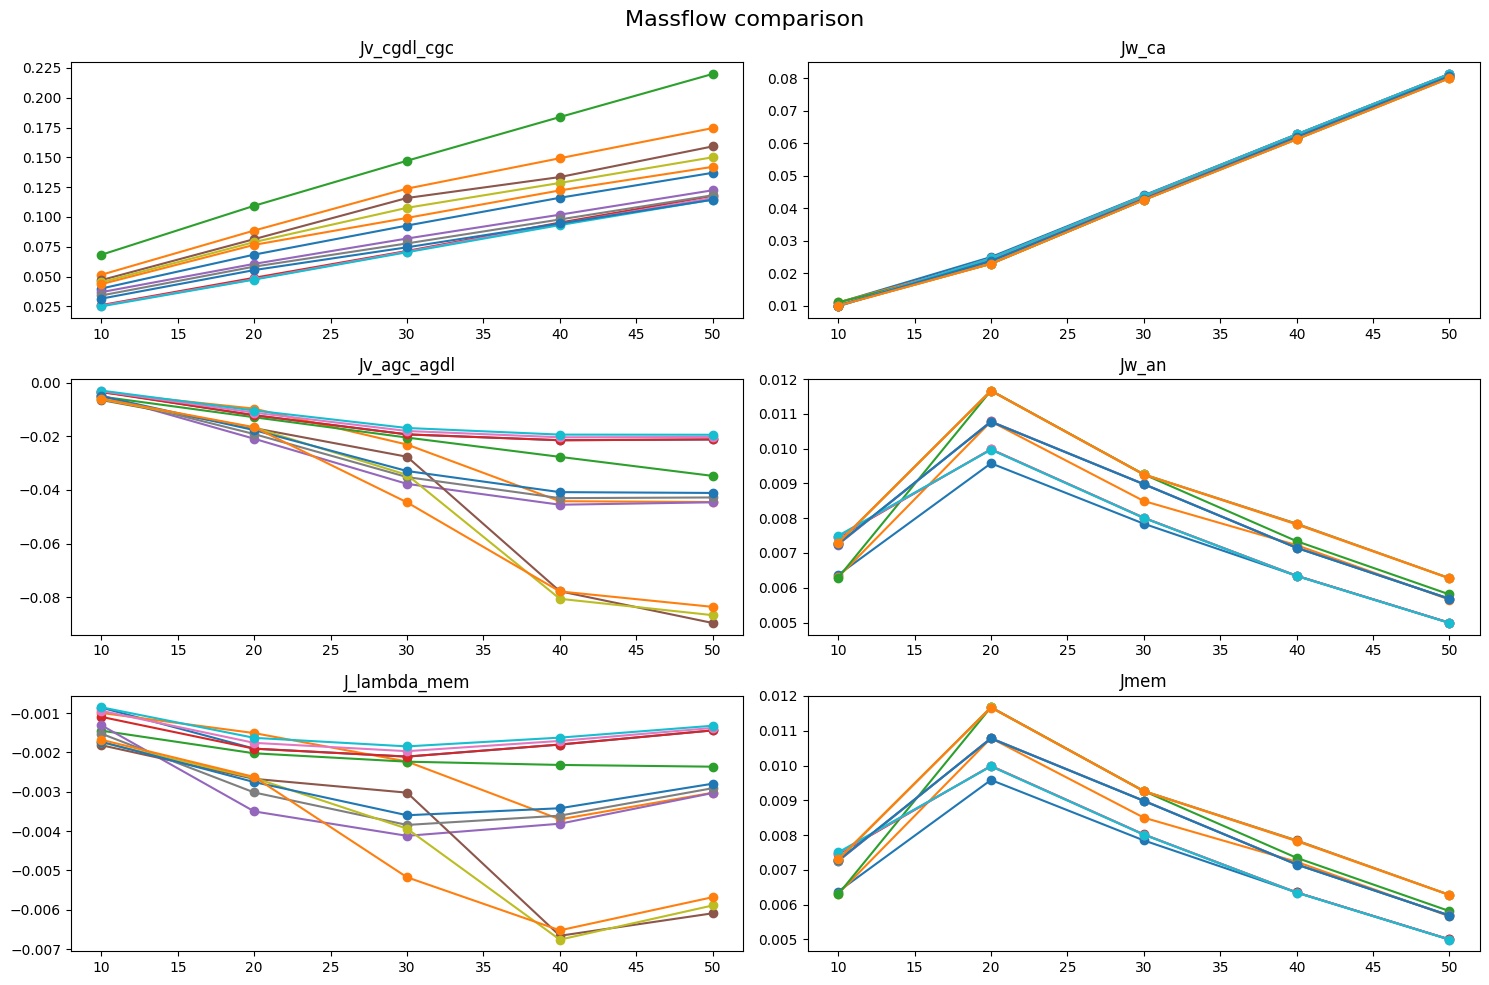

In [17]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 10))
fig.suptitle("Massflow comparison", fontsize=16)

for key in dyn_log_all.keys():
    states_dyn = dyn_log_all[key]["states"]
    time_evolutions = dyn_log_all[key]["time_evolution"]
    massflow_dyn = dyn_log_all[key]["massflow"]
    states_stat = stat_log_all[key]["states"]
    axes[0,0].plot(I_points, [massflow["Jv_cgdl_cgdl"][4] for massflow in massflow_dyn], label=key, marker='o')
    axes[0,1].plot(I_points, [states["Jw_ca"] for states in states_stat], label=key, marker='o')
    axes[1,0].plot(I_points, [massflow["Jv_agc_agdl"] for massflow in massflow_dyn], label=key, marker='o')
    axes[1,1].plot(I_points, [states["Jw_an"] for states in states_stat], label=key, marker='o')
    axes[2,0].plot(I_points, [massflow["J_lambda_mem"][4] for massflow in massflow_dyn], label=key, marker='o')
    axes[2,1].plot(I_points, [states["Jmem"] for states in states_stat], label=key, marker='o')

axes[0,0].set_title("Jv_cgdl_cgc")
axes[0,1].set_title("Jw_ca")
axes[1,0].set_title("Jv_agc_agdl")
axes[1,1].set_title("Jw_an")
axes[2,0].set_title("J_lambda_mem")
axes[2,1].set_title("Jmem")

plt.tight_layout()

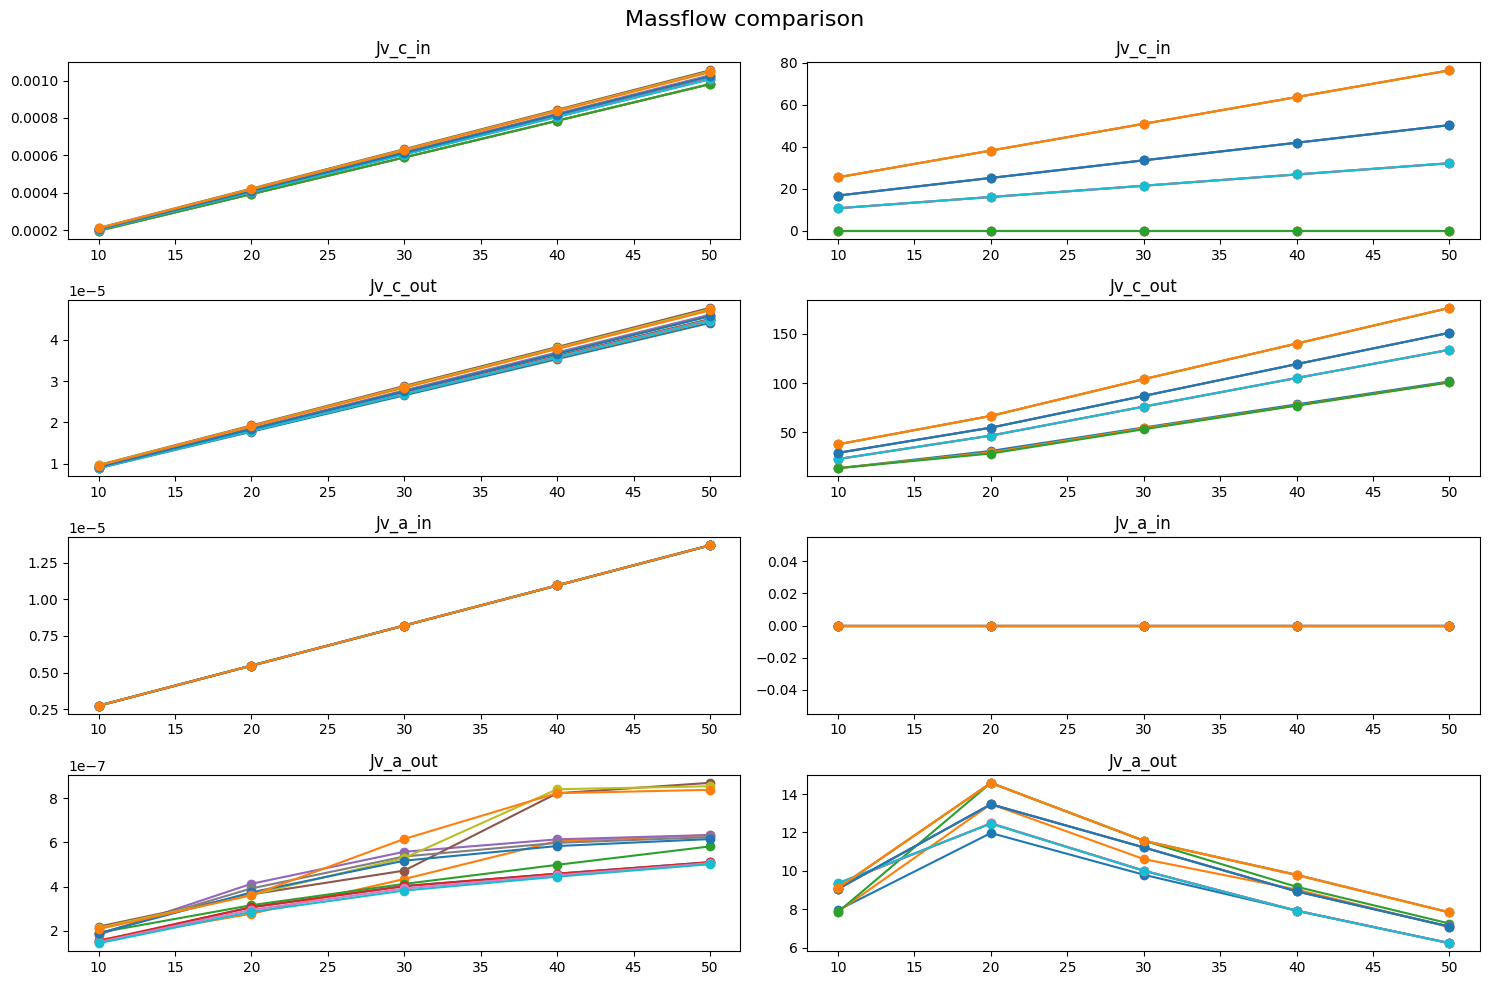

In [18]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 10))
fig.suptitle("Massflow comparison", fontsize=16)

for key in dyn_log_all.keys():
        states_dyn = dyn_log_all[key]["states"]
        time_evolutions = dyn_log_all[key]["time_evolution"]
        massflow_dyn = dyn_log_all[key]["massflow"]
        states_stat = stat_log_all[key]["states"]
        axes[0,0].plot(I_points, [massflow["Wcsm_in"] for massflow in massflow_dyn], label=key, marker='o')
        axes[0,1].plot(I_points, [states["Jv_c_in"] for states in states_stat], label=key, marker='o')
        axes[1,0].plot(I_points, [massflow["Wcem_in"] for massflow in massflow_dyn], label=key, marker='o')
        axes[1,1].plot(I_points, [states["Jv_c_out"] for states in states_stat], label=key, marker='o')
        axes[2,0].plot(I_points, [massflow["Wasm_in"] for massflow in massflow_dyn], label=key, marker='o')
        axes[2,1].plot(I_points, [states["Jv_a_in"] for states in states_stat], label=key, marker='o')
        axes[3,0].plot(I_points, [massflow["Waem_in"] for massflow in massflow_dyn], label=key, marker='o')
        axes[3,1].plot(I_points, [states["Jv_a_out"] for states in states_stat], label=key, marker='o')

axes[0,0].set_title("Jv_c_in")
axes[0,1].set_title("Jv_c_in")
axes[1,0].set_title("Jv_c_out")
axes[1,1].set_title("Jv_c_out")
axes[2,0].set_title("Jv_a_in")
axes[2,1].set_title("Jv_a_in")
axes[3,0].set_title("Jv_a_out")
axes[3,1].set_title("Jv_a_out")

plt.tight_layout()